In [1]:
!pip install pandas pandas-datareader matplotlib

  Using cached lxml-6.0.2-cp312-cp312-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (3.6 kB)
Using cached lxml-6.0.2-cp312-cp312-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas-datareader]


--- Начало загрузки данных из Всемирного Банка (World Bank API) ---
--- Данные успешно загружены и обработаны ---

Фактические загруженные данные (Текущий счет, % ВВП):
Country     Китай  Германия  Саудовская Аравия       США
Year                                                    
2019     0.706790  7.880059           4.325751 -2.051822
2020     1.659301  6.349851          -3.326675 -2.779344
2021     1.938752  6.931137           4.124884 -3.625809
2022     2.420593  3.885067          12.134331 -3.818765
2023     1.441583  5.556686           2.883121 -3.347739
2024     2.261650  5.665836          -0.464627 -4.061328


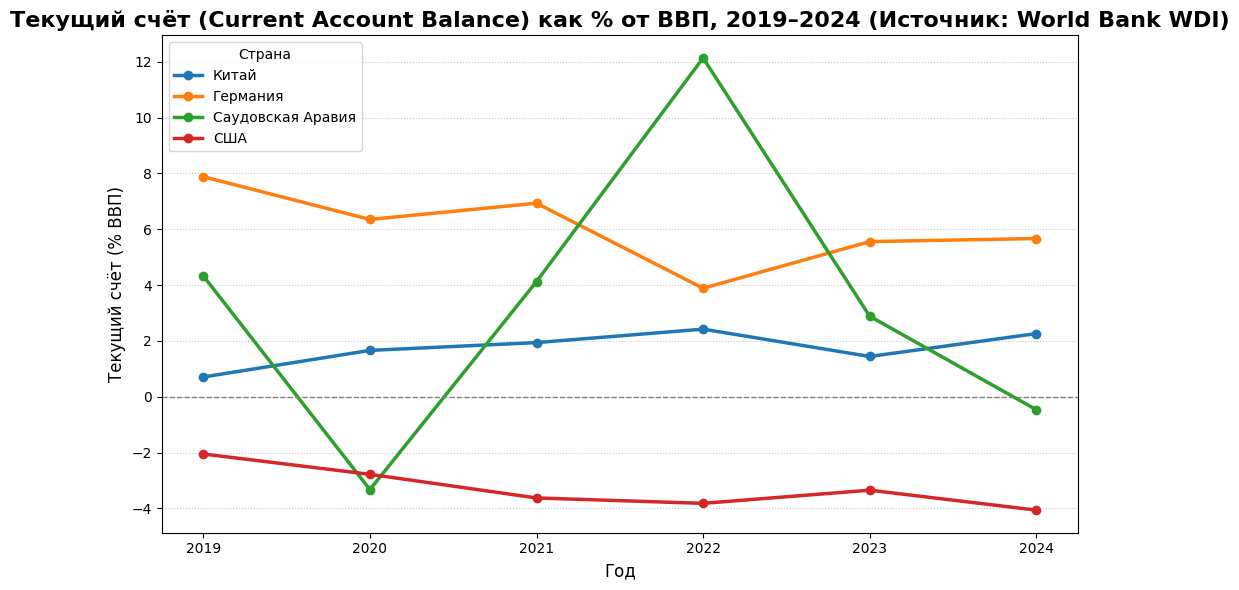

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import warnings

# Отключаем предупреждения
warnings.filterwarnings("ignore")

# --- 1. Параметры для загрузки данных ---
# Код индикатора Всемирного банка для "Current account balance (% of GDP)"
INDICATOR_CODE = 'BN.CAB.XOKA.GD.ZS' 
# Коды стран (ISO-2, для прямого API лучше использовать ISO-2)
# США: US, Китай: CN, Германия: DE, Саудовская Аравия: SA
COUNTRIES = ['US', 'CN', 'DE', 'SA'] 
COUNTRY_NAMES = {
    'US': 'США',
    'CN': 'Китай',
    'DE': 'Германия',
    'SA': 'Саудовская Аравия'
}
START_YEAR = 2019
END_YEAR = 2024
BASE_URL = "http://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"


def fetch_world_bank_data():
    """Загружает данные напрямую через API Всемирного банка."""
    url = BASE_URL.format(
        countries=';'.join(COUNTRIES),
        indicator=INDICATOR_CODE
    )
    # Параметры запроса: формат JSON, временной диапазон, лимит записей
    params = {
        'format': 'json',
        'date': f'{START_YEAR}:{END_YEAR}',
        'per_page': 500  # Достаточно большой лимит для 4 стран и 6 лет
    }
    
    print("--- Начало загрузки данных из Всемирного Банка (World Bank API) ---")
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()  # Вызовет исключение, если статус 4xx или 5xx
        
        data = response.json()
        
        # Проверяем, что данные успешно получены (API возвращает список: [мета, данные])
        if len(data) < 2 or data[1] is None:
            print("API не вернул данных. Проверьте коды индикатора/страны.")
            return None
        
        # Преобразуем JSON в DataFrame
        records = []
        for item in data[1]:
            if item['value'] is not None:
                records.append({
                    'Country': item['countryiso3code'], # ISO-3 для переименования
                    'Year': int(item['date']),
                    'CA_Balance': float(item['value'])
                })
        
        df = pd.DataFrame(records)
        if df.empty:
            print("Данные загружены, но отсутствуют значения для указанного периода.")
            return None
            
        # Преобразование в формат, удобный для построения графика
        df_pivot = df.pivot(index='Year', columns='Country', values='CA_Balance')
        
        # Переименовываем колонки с ISO-3 на русские названия
        df_pivot = df_pivot.rename(columns={k: v for k, v in zip(['USA', 'CHN', 'DEU', 'SAU'], COUNTRY_NAMES.values())})

        return df_pivot

    except requests.exceptions.RequestException as e:
        print(f"Критическая ошибка при выполнении HTTP-запроса: {e}")
        return None
    except Exception as e:
        print(f"Ошибка при обработке данных: {e}")
        return None


# --- Основное выполнение ---
df_plot = fetch_world_bank_data()

if df_plot is not None:
    print("--- Данные успешно загружены и обработаны ---")
    
    # Заменяем пропущенные (NaN) значения нулями, если данные за 2024 год еще не вышли
    df_plot = df_plot.fillna(0)
    
    print("\nФактические загруженные данные (Текущий счет, % ВВП):")
    print(df_plot)

    # --- 4. Построение графика ---
    plt.figure(figsize=(10, 6))

    # Построение линий для каждой страны
    df_plot.plot(ax=plt.gca(), marker='o', linewidth=2.5) 

    # Добавляем горизонтальную линию для нуля
    plt.axhline(0, color='grey', linestyle='--', linewidth=1) 

    # Настройка заголовка и осей
    plt.title(
        'Текущий счёт (Current Account Balance) как % от ВВП, 2019–2024 (Источник: World Bank WDI)',
        fontsize=16, 
        fontweight='bold'
    )
    plt.xlabel('Год', fontsize=12)
    plt.ylabel('Текущий счёт (% ВВП)', fontsize=12)
    plt.legend(title='Страна', loc='upper left')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.xticks(df_plot.index) # Гарантируем, что на оси X только полные годы
    plt.tight_layout()

    # Сохранение и